<h1>2D Fiber Scattering Example</h1>

Load a saved matter-interface geometry, then run a one-photon scattering experiment.

In [87]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
import numpy as np

resol = 160
plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

cwd = Path().resolve()
project_root = next(path for path in (cwd, *cwd.parents) if (path / "src").exists())
sys.path.append(str(project_root))

from src.experiment import Experiment
from src.fiber_geometry import (
    geometry_filename,
    load_geometry_csv,
    make_fiber_config,
    plot_fiber_geometry,
    plot_slab_geometry,
    radius_label,
    slab_geometry_filename,
)

from src.two_dimensional_renormalization import get_2d_bare_parameters


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<h2>Load matter geometry</h2>

In [88]:
geometry_kind = "slab"  # "disk" or "slab"

N_A = 5
interface_radius = 1
N_layer = 1

geometry_dir = project_root / "2d_setup" / "geometries"
if geometry_kind == "disk":
    geometry_path = geometry_dir / geometry_filename(N_A, interface_radius)
elif geometry_kind == "slab":
    geometry_path = geometry_dir / slab_geometry_filename(N_A, N_layer)
else:
    raise ValueError("geometry_kind must be 'disk' or 'slab'.")

if not geometry_path.exists():
    raise FileNotFoundError(
        f"Geometry file not found: {geometry_path}. "
        "Run 2d_setup/notebooks/geometry_creation.ipynb first."
    )

geometry = load_geometry_csv(geometry_path)
L1 = geometry["L1"]
L2 = geometry["L2"]
N_A = geometry["N_A"]
interface_radius = geometry.get("interface_radius", np.nan)
N_layer = geometry.get("N_layer", 0)
atom_positions = geometry["atom_positions"]
loaded_geometry_kind = "slab" if N_layer > 0 else "disk"

print(f"Loaded geometry: {geometry_path.name}")
if loaded_geometry_kind == "disk":
    print(f"L1={L1:g}, L2={L2:g}, N_A={N_A}, R={interface_radius:g}")
else:
    print(f"L1={L1:g}, L2={L2:g}, N_A={N_A}, N_layer={N_layer}")


Loaded geometry: matter_geom_NA5_NL1.csv
L1=50, L2=0.1, N_A=5, N_layer=1


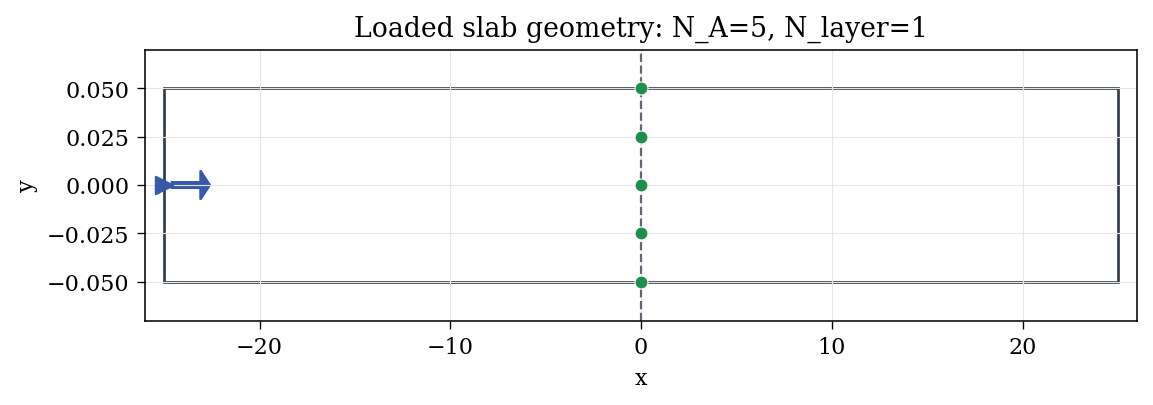

In [89]:
fig, ax = plt.subplots(figsize=(8.0, 2.2), dpi=resol)
if loaded_geometry_kind == "disk":
    plot_fiber_geometry(
        ax,
        L1=L1,
        L2=L2,
        atom_positions=atom_positions,
        interface_radius=interface_radius,
        photon_position=(-L1 / 2, 0.0),
    )
    ax.set_title(f"Loaded matter geometry: N_A={N_A}, R={interface_radius:g}")
else:
    plot_slab_geometry(
        ax,
        L1=L1,
        L2=L2,
        atom_positions=atom_positions,
        n_layers=N_layer,
        photon_position=(-L1 / 2, 0.0),
    )
    ax.set_title(f"Loaded slab geometry: N_A={N_A}, N_layer={N_layer}")
plt.show()


<h2>Experiment parameters</h2>

In [124]:
target_reference_cutoffs = {
    "ir_cutoff": 0 * np.pi,
    "uv_cutoff": 20 * np.pi,
}
target_window_label = (
    f"ref_{target_reference_cutoffs['ir_cutoff'] / np.pi:g}pi_"
    f"{target_reference_cutoffs['uv_cutoff'] / np.pi:g}pi"
).replace(".", "p")

if loaded_geometry_kind == "disk":
    geometry_label = f"NA{N_A}_R{radius_label(interface_radius)}"
else:
    geometry_label = f"NA{N_A}_NL{N_layer}"

target_profile_path = (
    project_root
    / "2d_setup"
    / "generate_target_profile"
    / f"target_profile_{geometry_label}_{target_window_label}.csv"
)
if not target_profile_path.exists():
    raise FileNotFoundError(
        f"Target profile not found: {target_profile_path}. "
        "Run 2d_setup/generate_target_profile/generate_target_profile.ipynb first."
    )

omega_init = 10 * np.pi
delta_k = 0.05 * np.pi

T = 50.0 /2
dt = 0.05
cutoffs = {
    "ir_cutoff": 3 * np.pi,
    "uv_cutoff": 11 * np.pi,
}

correction = True
radius_cache_decimals = 4 if loaded_geometry_kind == "slab" else 12

Omega_j, d_j, calibration_info = get_2d_bare_parameters(
    target_profile_path,
    atom_positions=atom_positions,
    cutoffs=cutoffs,
    correction=correction,
    fit_mode="uniform",
    cache_decimals=radius_cache_decimals,
    progress=True,
    return_diagnostics=True,
)

config = make_fiber_config(
    L1=L1,
    L2=L2,
    atom_positions=atom_positions,
    Omega_j=Omega_j,
    d_j=d_j,
    omega_init=omega_init,
    delta_k=delta_k,
    T=T,
    dt=dt,
    cutoffs=cutoffs,
)
scattering_experiment = Experiment(config)

print(f"Target profile: {target_profile_path.name}")
print(f"Correction enabled: {correction}")
print(f"Omega_j mean: {np.mean(Omega_j) / np.pi:.6f}π")
print(f"d_j mean: {np.mean(d_j):.6f}")
print(f"Retained photon modes: {scattering_experiment.n_modes}")
print(f"Frequency window: [{cutoffs['ir_cutoff']/np.pi:.2f}π, {cutoffs['uv_cutoff']/np.pi:.2f}π]")
if calibration_info.get("correction"):
    print(f"Calibration L2: {calibration_info['initial_l2']:.6e} -> {calibration_info['final_l2']:.6e}")


calibration: 0eval [00:00, ?eval/s]

Target profile: target_profile_NA5_NL1_ref_0pi_20pi.csv
Correction enabled: True
Omega_j mean: 10.006532π
d_j mean: 0.421798
Retained photon modes: 400
Frequency window: [3.00π, 11.00π]
Calibration L2: 3.620992e+00 -> 2.777928e+00


<h2>Run the propagation</h2>

In [125]:
c_array, b_array = scattering_experiment.propagate_state(progress=True)
messages = scattering_experiment.get_messages()

time_array = scattering_experiment.times
An_array, _, _ = scattering_experiment.compute_observables()

photon_density = np.abs(scattering_experiment.c_array) ** 2
px = scattering_experiment.momenta[:, 0]

right_moving_array = np.sum(photon_density[:, px > 0], axis=1)
left_moving_array = np.sum(photon_density[:, px < 0], axis=1)
vertical_array = np.sum(photon_density[:, np.isclose(px, 0.0)], axis=1)
total_array = right_moving_array + left_moving_array + vertical_array + An_array

print(f"Initial right-moving population: {right_moving_array[0]:.6f}")
print(f"Final right-moving population: {right_moving_array[-1]:.6f}")
print(f"Final left-moving population: {left_moving_array[-1]:.6f}")
print(f"Final atomic excitation: {An_array[-1]:.6f}")
print(f"Final vertical-mode population: {vertical_array[-1]:.2e}")
print(f"Final total probability: {total_array[-1]:.12f}")

100%|██████████| 500/500 [00:00<00:00, 7776.65it/s]

Initial right-moving population: 1.000000
Final right-moving population: 0.284005
Final left-moving population: 0.716067
Final atomic excitation: 0.000001
Final vertical-mode population: 0.00e+00
Final total probability: 1.000072953939


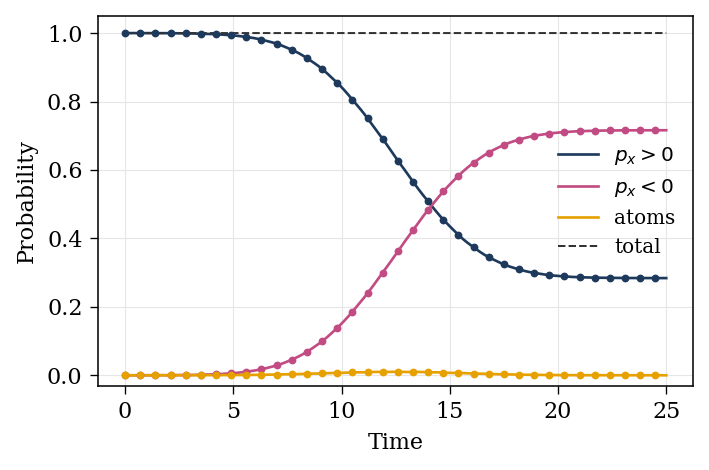

In [126]:
fig, ax = plt.subplots(figsize=(4.8, 3.0), dpi=resol)

step_marker = max(1, len(time_array) // 35)
color_right = "#1d3a5c"
color_left = "#c14b82"
color_atom = "#e6a100"

ax.plot(time_array, right_moving_array, color=color_right, lw=1.2, label=r"$p_x > 0$")
ax.plot(time_array, left_moving_array, color=color_left, lw=1.2, label=r"$p_x < 0$")
ax.plot(time_array, An_array, color=color_atom, lw=1.2, label="atoms")
ax.plot(time_array, total_array, color="0.2", lw=0.9, ls="--", label="total")

ax.plot(time_array[::step_marker], right_moving_array[::step_marker], "o", ms=2.5, color=color_right)
ax.plot(time_array[::step_marker], left_moving_array[::step_marker], "o", ms=2.5, color=color_left)
ax.plot(time_array[::step_marker], An_array[::step_marker], "o", ms=2.5, color=color_atom)

ax.set_xlabel("Time")
ax.set_ylabel("Probability")
ax.set_ylim(-0.03, 1.05)
ax.grid(color="0.9", linewidth=0.5)
ax.legend(frameon=False, fontsize=9)
plt.show()


<h2>Momentum-space photon distribution</h2>

Choose a physical time and plot $|c(p_x,p_y)|^2$ at the closest RK timestep.

In [105]:
soft_density_cmap = LinearSegmentedColormap.from_list(
    "soft_density",
    ["#f7f3e8", "#dcebed", "#9dc3cf", "#5f86ad", "#81608d", "#c06e68", "#f1cf79"],
)
boundary_color = "#5e6874"
plot_time = min(25.0, scattering_experiment.times[-1])

momentum_plot_mode = "auto"  # "auto", "density_2d", or "marginal_px"
momentum_x_axis_limit = None  # None: infer from cutoffs and populated modes
momentum_y_axis_limit = None  # only used by the 2D density plot
momentum_axis_padding = 0.75
momentum_transverse_mode_threshold = 1

momentum_color_scale = "power"  # "linear" or "power"
momentum_color_gamma = 0.45
momentum_vmax = None  # set to None to autoscale from momentum_vmax_quantile
momentum_vmax_quantile = 0.997
momentum_interpolation = "nearest"
momentum_aspect = "auto"

real_space_color_scale = "power"  # "linear" or "power"
real_space_color_gamma = 0.65
real_space_interpolation = "bicubic"
real_space_nx_plot = 360
real_space_min_ny_plot = 48
real_space_max_ny_plot = 180
real_space_display_min_aspect = 0.14


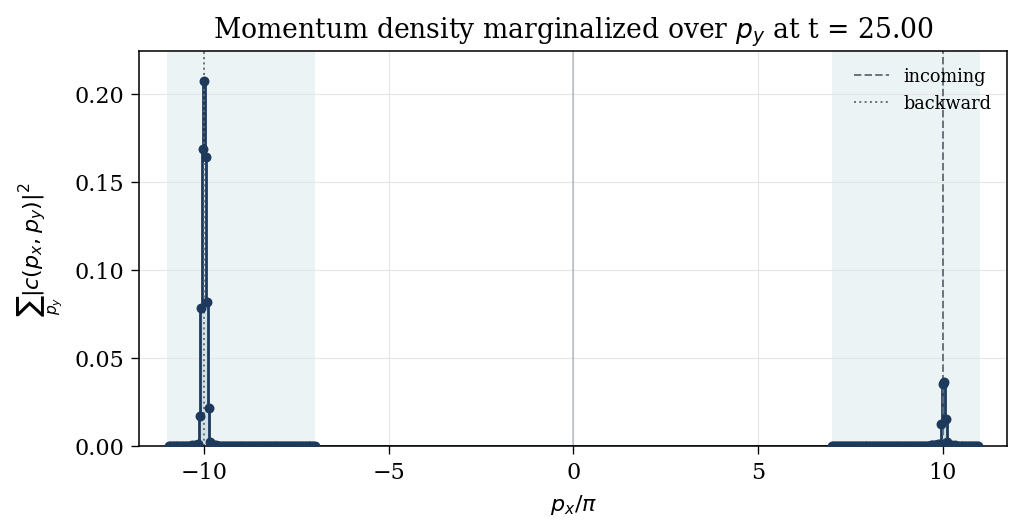

Requested time: 25.000
Closest RK time: 25.000
RK index: 500
Momentum plot mode: marginal_px
Retained transverse mode indices: [0]
Right-moving photon probability: 0.103404259764
Left-moving photon probability: 0.742316142573
Total photon probability: 0.845720402337
Total plotted probability: 0.845720402337
Momentum x-axis limit: ±11.75π
Momentum color scale: power
Momentum color gamma: 0.450
Momentum color vmax: 1.843556e-01
Probability above color vmax: 0.207469330520


In [106]:
time_index = int(np.argmin(np.abs(scattering_experiment.times - plot_time)))
actual_time = scattering_experiment.times[time_index]
momentum_probability = np.abs(scattering_experiment.c_array[time_index]) ** 2

momenta = scattering_experiment.momenta
momenta_pi = momenta / np.pi
mode_indices = scattering_experiment.mode_indices
delta_p = 2 * np.pi / scattering_experiment.lengths
delta_p_pi = delta_p / np.pi
ir_radius = scattering_experiment.cutoffs["ir_cutoff"] / np.pi
uv_radius = scattering_experiment.cutoffs["uv_cutoff"] / np.pi

positive_values = momentum_probability[momentum_probability > 0]
if momentum_vmax is None:
    plot_vmax = np.quantile(positive_values, momentum_vmax_quantile) if len(positive_values) else 1.0
    plot_vmax = max(plot_vmax, momentum_probability.max() * 1e-6, 1e-15)
else:
    plot_vmax = float(momentum_vmax)

if scattering_experiment.dimension >= 2:
    transverse_indices = np.unique(mode_indices[:, 1])
else:
    transverse_indices = np.array([0])

resolved_momentum_plot_mode = momentum_plot_mode
if resolved_momentum_plot_mode == "auto":
    if scattering_experiment.dimension == 2 and len(transverse_indices) <= momentum_transverse_mode_threshold:
        resolved_momentum_plot_mode = "marginal_px"
    else:
        resolved_momentum_plot_mode = "density_2d"

significant_mask = momentum_probability > max(momentum_probability.max() * 1e-10, 1e-15)

if resolved_momentum_plot_mode == "marginal_px":
    unique_nx, nx_inverse = np.unique(mode_indices[:, 0], return_inverse=True)
    px_axis = unique_nx * delta_p_pi[0]
    px_probability = np.zeros(len(unique_nx), dtype=float)
    np.add.at(px_probability, nx_inverse, momentum_probability)

    populated_px = px_axis[px_probability > max(px_probability.max() * 1e-10, 1e-15)]
    if momentum_x_axis_limit is None:
        populated_limit = np.max(np.abs(populated_px)) if len(populated_px) else 0.0
        x_axis_limit = max(uv_radius, populated_limit) + max(delta_p_pi[0], momentum_axis_padding)
    else:
        x_axis_limit = float(momentum_x_axis_limit)

    fig, ax = plt.subplots(figsize=(7.0, 3.2), dpi=resol)
    ax.axvspan(-uv_radius, -ir_radius, color="#d7e6e9", alpha=0.45, linewidth=0)
    ax.axvspan(ir_radius, uv_radius, color="#d7e6e9", alpha=0.45, linewidth=0)
    ax.fill_between(px_axis, 0.0, px_probability, step="mid", color="#9dc3cf", alpha=0.38, linewidth=0)
    ax.plot(px_axis, px_probability, color="#1d3a5c", lw=1.25, drawstyle="steps-mid")
    ax.scatter(px_axis, px_probability, s=12, color="#1d3a5c", zorder=3)
    ax.axvline(omega_init / np.pi, color=boundary_color, lw=0.9, ls="--", alpha=0.9, label="incoming")
    ax.axvline(-omega_init / np.pi, color=boundary_color, lw=0.9, ls=":", alpha=0.9, label="backward")
    ax.axvline(0.0, color=boundary_color, lw=0.8, alpha=0.35)
    ax.set_xlabel(r"$p_x / \pi$")
    ax.set_ylabel(r"$\sum_{p_y}|c(p_x,p_y)|^2$")
    ax.set_xlim(-x_axis_limit, x_axis_limit)
    ax.set_ylim(0.0, max(px_probability.max() * 1.08, 1e-15))
    ax.set_title(f"Momentum density marginalized over $p_y$ at t = {actual_time:.2f}")
    ax.grid(color="0.9", linewidth=0.5)
    ax.legend(frameon=False, loc="upper right", fontsize=8)
    plt.show()

    plotted_probability = px_probability.sum()
    x_limit_report = x_axis_limit
    y_limit_report = None

elif resolved_momentum_plot_mode == "density_2d":
    if momentum_x_axis_limit is None:
        x_axis_limit = uv_radius + max(delta_p_pi[0], momentum_axis_padding)
    else:
        x_axis_limit = float(momentum_x_axis_limit)
    if momentum_y_axis_limit is None:
        y_axis_limit = uv_radius + max(delta_p_pi[1], momentum_axis_padding)
    else:
        y_axis_limit = float(momentum_y_axis_limit)

    p_axis_limits = np.array([x_axis_limit, y_axis_limit]) * np.pi
    n_plot = np.floor(p_axis_limits / delta_p).astype(int)
    nx_values = np.arange(-n_plot[0], n_plot[0] + 1)
    ny_values = np.arange(-n_plot[1], n_plot[1] + 1)
    probability_grid = np.zeros((len(ny_values), len(nx_values)))

    ix = mode_indices[:, 0] + n_plot[0]
    iy = mode_indices[:, 1] + n_plot[1]
    inside_plot_window = (
        (ix >= 0)
        & (ix < len(nx_values))
        & (iy >= 0)
        & (iy < len(ny_values))
    )
    probability_grid[iy[inside_plot_window], ix[inside_plot_window]] = momentum_probability[inside_plot_window]

    extent = [
        (nx_values[0] - 0.5) * delta_p_pi[0],
        (nx_values[-1] + 0.5) * delta_p_pi[0],
        (ny_values[0] - 0.5) * delta_p_pi[1],
        (ny_values[-1] + 0.5) * delta_p_pi[1],
    ]

    image_kwargs = {
        "origin": "lower",
        "extent": extent,
        "cmap": soft_density_cmap,
        "interpolation": momentum_interpolation,
        "aspect": momentum_aspect,
    }
    if momentum_color_scale == "power":
        image_kwargs["norm"] = PowerNorm(gamma=momentum_color_gamma, vmin=0.0, vmax=plot_vmax)
    elif momentum_color_scale == "linear":
        image_kwargs["vmin"] = 0.0
        image_kwargs["vmax"] = plot_vmax
    else:
        raise ValueError("momentum_color_scale must be 'linear' or 'power'.")

    fig, ax = plt.subplots(figsize=(6.8, 4.4), dpi=resol)
    image = ax.imshow(probability_grid, **image_kwargs)

    theta = np.linspace(0, 2 * np.pi, 800)
    ax.plot(ir_radius * np.cos(theta), ir_radius * np.sin(theta), color=boundary_color, lw=1.0, ls="--", alpha=0.85, label="IR cutoff")
    ax.plot(uv_radius * np.cos(theta), uv_radius * np.sin(theta), color=boundary_color, lw=1.2, alpha=0.9, label="UV cutoff")
    ax.axvline(0.0, color=boundary_color, lw=0.8, ls=":", alpha=0.8)
    ax.axhline(0.0, color=boundary_color, lw=0.8, alpha=0.35)

    ax.set_xlabel(r"$p_x / \pi$")
    ax.set_ylabel(r"$p_y / \pi$")
    ax.set_xlim(-x_axis_limit, x_axis_limit)
    ax.set_ylim(-y_axis_limit, y_axis_limit)
    ax.set_title(f"Momentum density at t = {actual_time:.2f} (RK index {time_index})")
    ax.legend(frameon=False, loc="upper right", fontsize=8)

    cbar = fig.colorbar(image, ax=ax, pad=0.02)
    if momentum_color_scale == "power":
        cbar.set_label(r"$|c(p_x,p_y)|^2$ displayed with PowerNorm", rotation=270, labelpad=14)
    else:
        cbar.set_label(r"$|c(p_x,p_y)|^2$", rotation=270, labelpad=14)
    plt.show()

    plotted_probability = probability_grid.sum()
    x_limit_report = x_axis_limit
    y_limit_report = y_axis_limit

else:
    raise ValueError("momentum_plot_mode must be 'auto', 'density_2d', or 'marginal_px'.")

left_probability = momentum_probability[momenta[:, 0] < 0].sum()
right_probability = momentum_probability[momenta[:, 0] > 0].sum()
print(f"Requested time: {plot_time:.3f}")
print(f"Closest RK time: {actual_time:.3f}")
print(f"RK index: {time_index}")
print(f"Momentum plot mode: {resolved_momentum_plot_mode}")
print(f"Retained transverse mode indices: {transverse_indices.tolist()}")
print(f"Right-moving photon probability: {right_probability:.12f}")
print(f"Left-moving photon probability: {left_probability:.12f}")
print(f"Total photon probability: {momentum_probability.sum():.12f}")
print(f"Total plotted probability: {plotted_probability:.12f}")
print(f"Momentum x-axis limit: ±{x_limit_report:.2f}π")
if y_limit_report is not None:
    print(f"Momentum y-axis limit: ±{y_limit_report:.2f}π")
print(f"Momentum color scale: {momentum_color_scale}")
if momentum_color_scale == "power":
    print(f"Momentum color gamma: {momentum_color_gamma:.3f}")
print(f"Momentum color vmax: {plot_vmax:.6e}")
print(f"Probability above color vmax: {momentum_probability[momentum_probability > plot_vmax].sum():.12f}")


<h2>Real-space photon density</h2>

This cell is heavier: it reconstructs the Schrödinger-picture photon density from the retained momentum modes.

In [100]:
position_time_index = time_index
position_time = scattering_experiment.times[position_time_index]
position_amplitudes = (
    scattering_experiment.c_array[position_time_index]
    * np.exp(-1j * scattering_experiment.omega_tab * position_time)
    / np.sqrt(scattering_experiment.volume)
)

nx_plot = int(real_space_nx_plot)
ny_plot = int(
    np.clip(
        round(nx_plot * max(L2 / L1, real_space_display_min_aspect)),
        real_space_min_ny_plot,
        real_space_max_ny_plot,
    )
)
x_values = np.linspace(-L1 / 2, L1 / 2, nx_plot)
y_values = np.linspace(-L2 / 2, L2 / 2, ny_plot)
X, Y = np.meshgrid(x_values, y_values, indexing="xy")
points = np.column_stack((X.reshape(-1), Y.reshape(-1)))

psi_values = np.zeros(len(points), dtype=complex)
chunk_size = 800
for start in range(0, len(points), chunk_size):
    stop = min(start + chunk_size, len(points))
    phase = np.exp(1j * points[start:stop] @ scattering_experiment.momenta.T)
    psi_values[start:stop] = phase @ position_amplitudes

position_density = np.abs(psi_values.reshape(ny_plot, nx_plot)) ** 2
dx = x_values[1] - x_values[0]
dy = y_values[1] - y_values[0]
position_integral = np.sum(position_density) * dx * dy


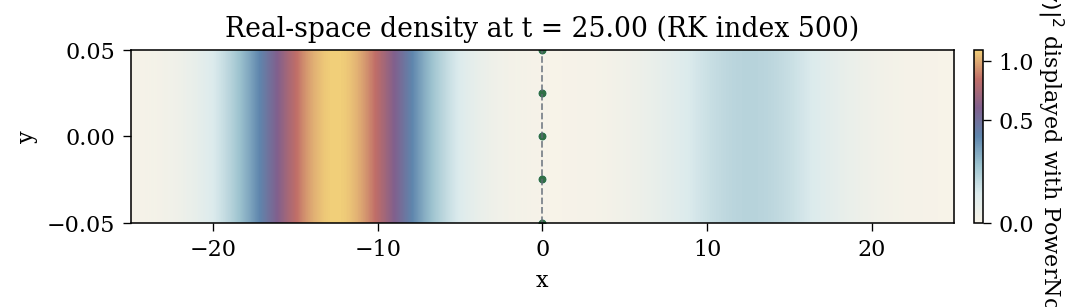

Position grid: 360 × 50
Position-density integral estimate: 1.020397369932
Momentum-space photon probability: 0.999982883647
Real-space color scale: power
Real-space color gamma: 0.650


In [101]:
position_vmax = max(position_density.max(), 1e-15)
position_image_kwargs = {
    "origin": "lower",
    "extent": [-L1 / 2, L1 / 2, -L2 / 2, L2 / 2],
    "cmap": soft_density_cmap,
    "interpolation": real_space_interpolation,
    "aspect": "auto",
}
if real_space_color_scale == "power":
    position_image_kwargs["norm"] = PowerNorm(gamma=real_space_color_gamma, vmin=0.0, vmax=position_vmax)
elif real_space_color_scale == "linear":
    position_image_kwargs["vmin"] = 0.0
    position_image_kwargs["vmax"] = position_vmax
else:
    raise ValueError("real_space_color_scale must be 'linear' or 'power'.")

real_space_fig_height = max(1.4, min(3.0, 8.0 * max(L2 / L1, real_space_display_min_aspect)))
fig, ax = plt.subplots(figsize=(8.0, real_space_fig_height), dpi=resol)
image = ax.imshow(position_density, **position_image_kwargs)
ax.scatter(atom_positions[:, 0], atom_positions[:, 1], s=16, color="#2f6f46", edgecolor="white", linewidth=0.35)
ax.axvline(0.0, color=boundary_color, lw=0.8, ls="--", alpha=0.8)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Real-space density at t = {position_time:.2f} (RK index {position_time_index})")
ax.set_xlim(-L1 / 2, L1 / 2)
ax.set_ylim(-L2 / 2, L2 / 2)

cbar = fig.colorbar(image, ax=ax, pad=0.02)
if real_space_color_scale == "power":
    cbar.set_label(r"$|\psi(x,y)|^2$ displayed with PowerNorm", rotation=270, labelpad=14)
else:
    cbar.set_label(r"$|\psi(x,y)|^2$", rotation=270, labelpad=14)
plt.show()

print(f"Position grid: {nx_plot} × {ny_plot}")
print(f"Position-density integral estimate: {position_integral:.12f}")
print(f"Momentum-space photon probability: {np.sum(np.abs(scattering_experiment.c_array[position_time_index]) ** 2):.12f}")
print(f"Real-space color scale: {real_space_color_scale}")
if real_space_color_scale == "power":
    print(f"Real-space color gamma: {real_space_color_gamma:.3f}")
